Logistic regression
Scenario: Predicting Customer Churn for a telecom company.


---
 1.Data Creation



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 110
N = 1500
# Numerical features
tenure          = np.random.randint(1, 73, N)                      
monthly_charges = np.round(np.random.uniform(20, 120, N), 2)
total_charges   = np.round(tenure * monthly_charges + np.random.normal(0, 50, N), 2)
support_calls   = np.random.poisson(lam=2, size=N)
age             = np.random.randint(18, 75, N)
# Categorical features
contract_type   = np.random.choice(['Month-to-Month', 'One Year', 'Two Year'],
                                    N, p=[0.55, 0.25, 0.20])
payment_method  = np.random.choice(['Electronic Check', 'Mailed Check',
                                    'Bank Transfer', 'Credit Card'], N)
# Target: churn (imbalanced — ~25% churn)
churn_prob = (
    0.4 * (tenure < 12).astype(float) +
    0.3 * (monthly_charges > 80).astype(float) +
    0.2 * (support_calls > 3).astype(float) +
    0.3 * (contract_type == 'Month-to-Month').astype(float) -
    0.2 * (contract_type == 'Two Year').astype(float) +
    np.random.uniform(0, 0.1, N)
)
churn_prob = np.clip(churn_prob / churn_prob.max(), 0.05, 0.90)
churn = (np.random.rand(N) < churn_prob).astype(int)
df = pd.DataFrame({
    'age': age,
    'tenure': tenure,
    'monthly_charges': monthly_charges,
    'total_charges': total_charges,
    'support_calls': support_calls,
    'contract_type': contract_type,
    'payment_method': payment_method,
    'churn': churn 
})
#Inject Missing Values 
for col, rate in [('monthly_charges', 0.05), ('total_charges', 0.06),
                  ('support_calls', 0.04), ('contract_type', 0.03)]:
    mask = np.random.rand(N) < rate
    df.loc[mask, col] = np.nan
#Inject Outliers
outlier_idx = np.random.choice(N, 15, replace=False)
df.loc[outlier_idx[:8],  'monthly_charges'] = np.random.uniform(300, 500, 8)
df.loc[outlier_idx[8:],  'support_calls']   = np.random.randint(25, 50, 7)
print("Dataset shape:", df.shape)
print("\nChurn distribution:")
print(df['churn'].value_counts())
print(f"\nChurn rate: {df['churn'].mean()*100:.1f}%")
df.head(10)


Dataset shape: (1500, 8)

Churn distribution:
churn
0    1016
1     484
Name: count, dtype: int64

Churn rate: 32.3%


,age,tenure,monthly_charges,total_charges,support_calls,contract_type,payment_method,churn
0,30,52,107.18,5510.84,1.0,One Year,Mailed Check,0
1,61,15,41.92,659.03,2.0,Two Year,Bank Transfer,0
2,64,72,117.59,8510.60,3.0,Month-to-Month,Credit Card,0
3,26,61,53.69,3252.49,2.0,Two Year,Bank Transfer,0
4,51,21,38.21,NaN,NaN,Month-to-Month,Electronic Check,0
5,34,24,98.97,2388.57,2.0,Month-to-Month,Mailed Check,1
6,44,3,85.87,NaN,2.0,Month-to-Month,Electronic Check,1
7,46,22,69.82,1532.73,2.0,Month-to-Month,Bank Transfer,0
8,54,53,75.54,4108.61,3.0,Two Year,Mailed Check,0
9,60,2,91.92,171.49,2.0,NaN,Electronic Check,1


---
 2.Exploratory Data Analysis (EDA)


In [ ]:
print("Dataset Info")
df.info()
print("\n Summary Statistics ")
df.describe()


Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              1500 non-null   int32  
 1   tenure           1500 non-null   int32  
 2   monthly_charges  1413 non-null   float64
 3   total_charges    1420 non-null   float64
 4   support_calls    1450 non-null   float64
 5   contract_type    1461 non-null   str    
 6   payment_method   1500 non-null   str    
 7   churn            1500 non-null   int64  
dtypes: float64(3), int32(2), int64(1), str(2)
memory usage: 82.2 KB

 Summary Statistics 


,age,tenure,monthly_charges,total_charges,support_calls,churn
count,1500.000000,1500.000000,1413.000000,1420.000000,1450.000000,1500.000000
mean,45.643333,35.870667,72.277534,2509.711070,2.082759,0.322667
std,16.727702,20.857228,39.542708,1854.648783,2.748495,0.467652
min,18.000000,1.000000,20.010000,-16.750000,0.000000,0.000000
25%,31.000000,17.000000,45.760000,999.137500,1.000000,0.000000
50%,45.000000,36.000000,70.940000,2100.860000,2.000000,0.000000
75%,61.000000,54.000000,95.680000,3649.997500,3.000000,1.000000
max,74.000000,72.000000,487.996657,8669.860000,49.000000,1.000000


Missing Values:
                  Missing Count  Missing %
monthly_charges             87       5.80
total_charges               80       5.33
support_calls               50       3.33
contract_type               39       2.60


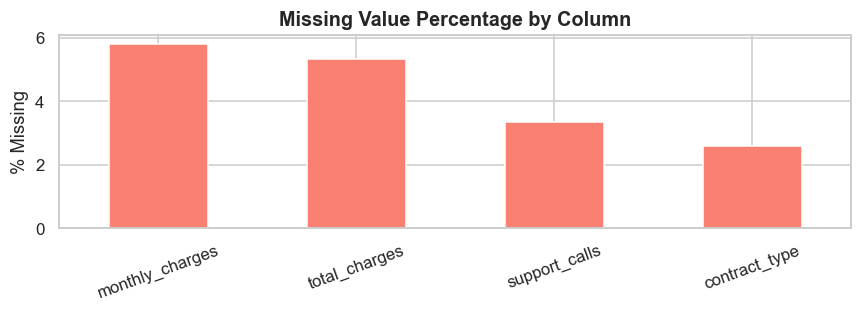

In [ ]:
#Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing Values:\n", missing_df[missing_df['Missing Count'] > 0])
fig, ax = plt.subplots(figsize=(8, 3))
missing_pct[missing_pct > 0].plot(kind='bar', color='salmon', ax=ax)
ax.set_title('Missing Value Percentage by Column', fontsize=13, fontweight='bold')
ax.set_ylabel('% Missing')
ax.set_xlabel('')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


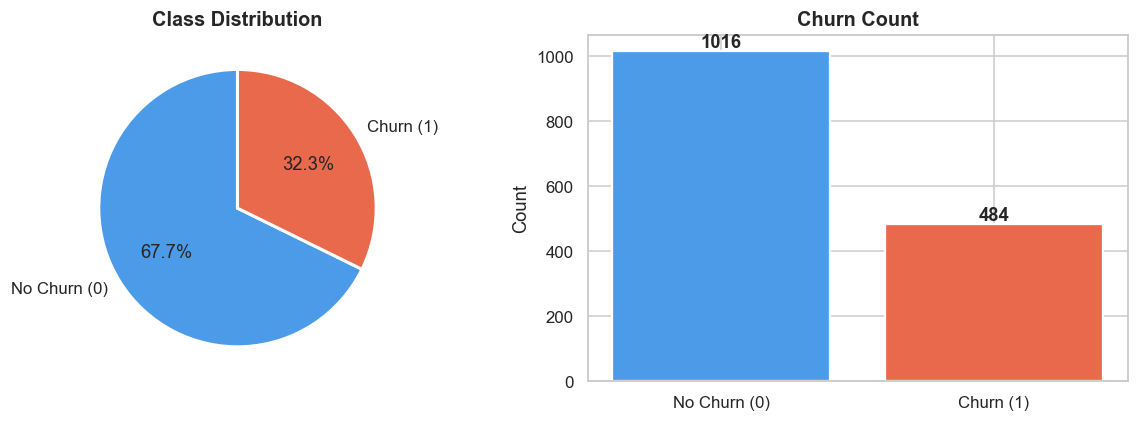


Imbalanced classes detected. Accuracy alone will be misleading.
   We'll use Precision, Recall, F1, and ROC-AUC as primary metrics.


In [ ]:
#Class Balance
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = df['churn'].value_counts()
labels = ['No Churn (0)', 'Churn (1)']
colors = ['#4C9BE8', '#E8694C']
axes[0].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[1].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print("\nImbalanced classes detected. Accuracy alone will be misleading.")
print("   We'll use Precision, Recall, F1, and ROC-AUC as primary metrics.")


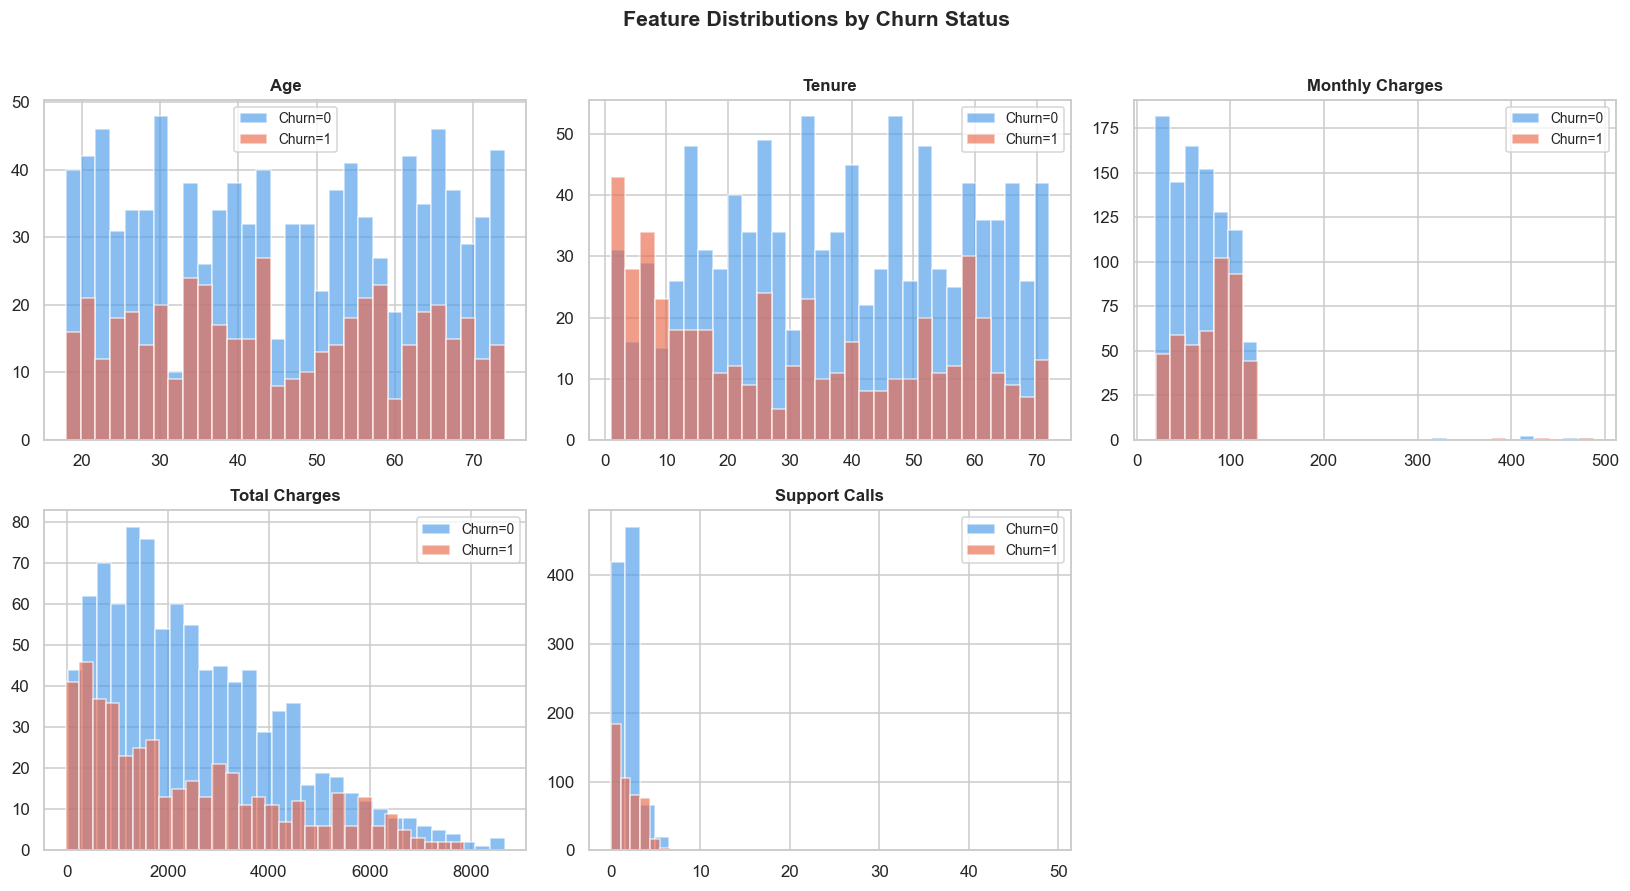

In [ ]:
#Numerical Feature Distributions by Churn
num_cols = ['age', 'tenure', 'monthly_charges', 'total_charges', 'support_calls']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for label, color in zip([0, 1], ['#4C9BE8','#E8694C']):
        subset = df[df['churn'] == label][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.65, label=f'Churn={label}',
                     color=color, edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)
axes[5].set_visible(False)
plt.suptitle('Feature Distributions by Churn Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


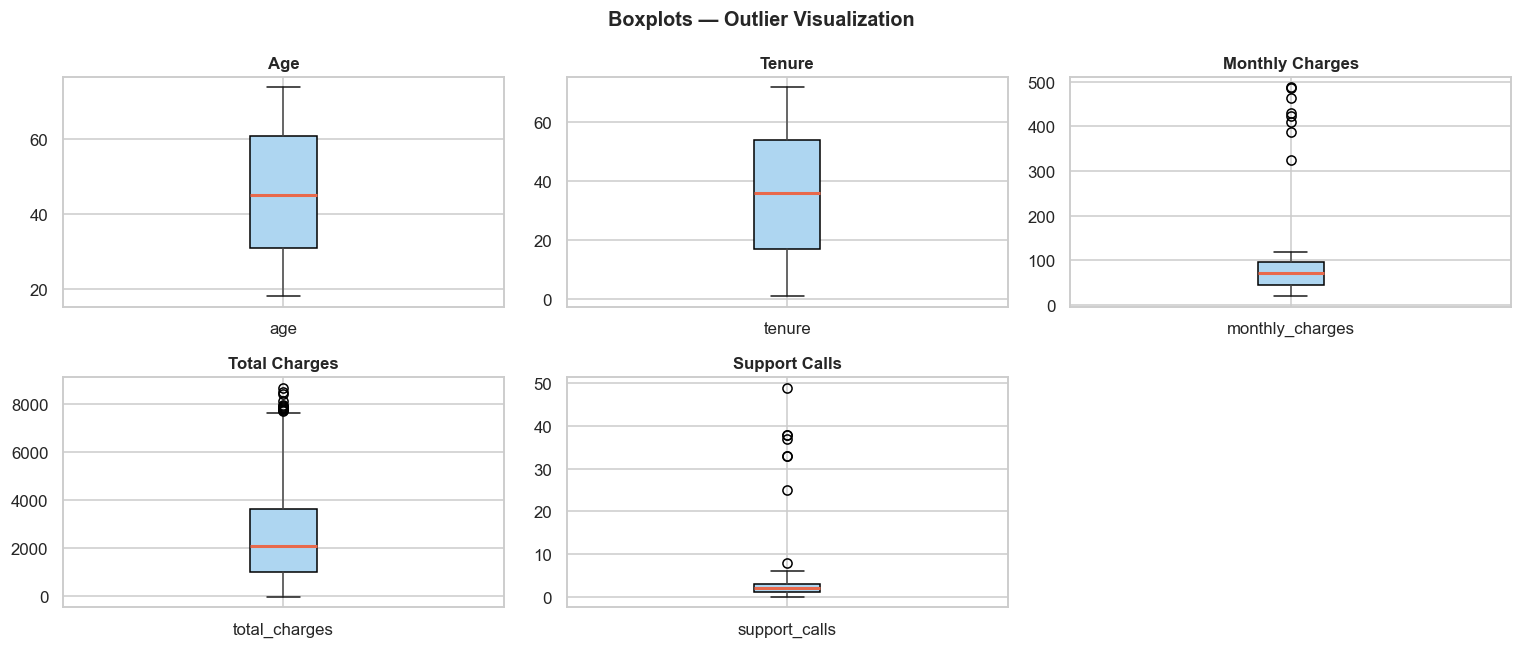

Outliers visible in monthly_charges (>300) and support_calls (>20) and Total charges.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()  
cols = ['age', 'tenure', 'monthly_charges', 'total_charges', 'support_calls']
for ax, col in zip(axes, cols):
    df.boxplot(column=col, ax=ax, patch_artist=True,
               boxprops=dict(facecolor='#AED6F1'),
               medianprops=dict(color='#E8694C', linewidth=2))
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
axes[len(cols)].set_visible(False)
plt.suptitle('Boxplots — Outlier Visualization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Outliers visible in monthly_charges (>300) and support_calls (>20) and Total charges.")

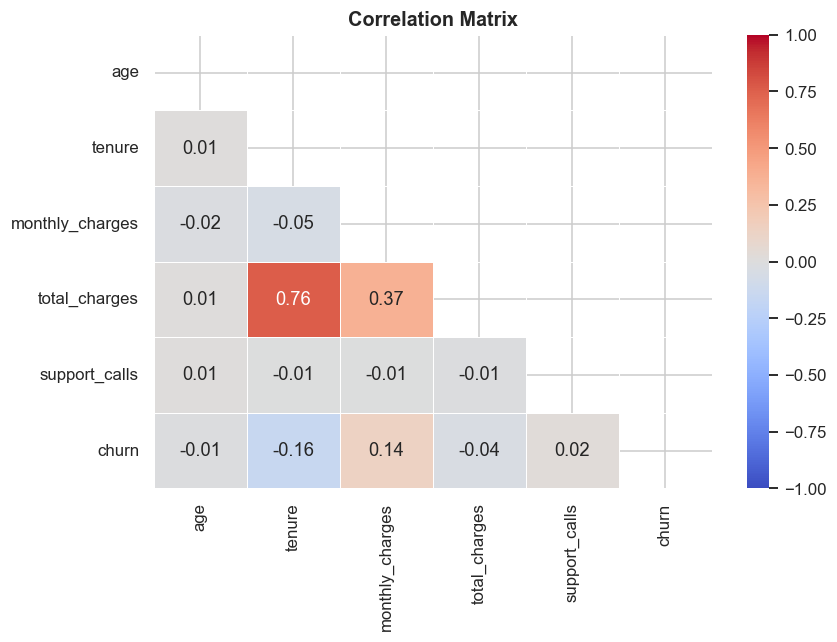


 Key observation:
   'total_charges' is highly correlated with 'tenure' and 'monthly_charges'.
   This is multicollinearity — we will DROP 'total_charges' to avoid it.


In [ ]:
corr = df[num_cols + ['churn']].corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n Key observation:")
print("   'total_charges' is highly correlated with 'tenure' and 'monthly_charges'.")
print("   This is multicollinearity — we will DROP 'total_charges' to avoid it.")


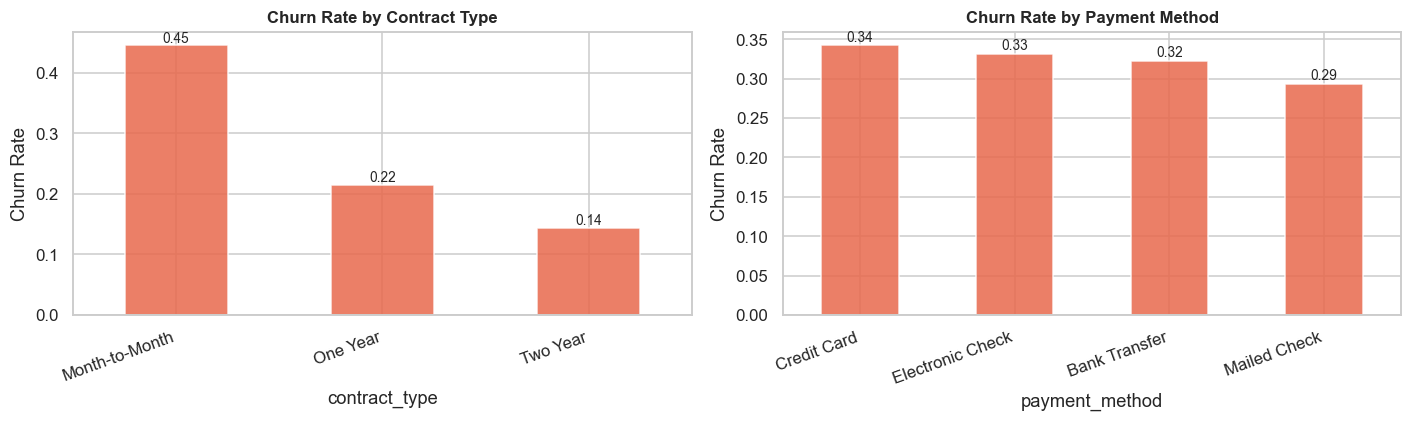


Month-to-Month contracts have the highest churn rate — intuitive!


In [ ]:
#Categorical Features vs Churn
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ['contract_type', 'payment_method']):
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='#E8694C', edgecolor='white', alpha=0.85)
    ax.set_title(f'Churn Rate by {col.replace("_"," ").title()}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Churn Rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x()+p.get_width()/2, p.get_height()+0.005),
                    ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print("\nMonth-to-Month contracts have the highest churn rate — intuitive!")


---
3.Data Preprocessing



In [ ]:
#Step 1: Drop Multicollinear Feature
df_clean = df.drop(columns=['total_charges'])
print("Dropped 'total_charges' due to high multicollinearity.")
print("Remaining columns:", df_clean.columns.tolist())


Dropped 'total_charges' due to high multicollinearity.
Remaining columns: ['age', 'tenure', 'monthly_charges', 'support_calls', 'contract_type', 'payment_method', 'churn']


In [ ]:
#Step 2: Handle Missing Values
num_features  = ['age', 'tenure', 'monthly_charges', 'support_calls']
cat_features  = ['contract_type', 'payment_method']
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
df_clean[num_features] = num_imputer.fit_transform(df_clean[num_features])
df_clean[cat_features] = cat_imputer.fit_transform(df_clean[cat_features])
print("Missing values after imputation:")
print(df_clean.isnull().sum())


Missing values after imputation:
age                0
tenure             0
monthly_charges    0
support_calls      0
contract_type      0
payment_method     0
churn              0
dtype: int64


In [ ]:
#Step 3: Outlier Treatment (IQR Capping)
def cap_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return series.clip(lower, upper)
for col in ['monthly_charges', 'support_calls']:
    before_max = df_clean[col].max()
    df_clean[col] = cap_outliers(df_clean[col])
    after_max  = df_clean[col].max()
    print(f"{col}: max before={before_max:.1f}, max after={after_max:.1f}")
print("\nOutliers capped at IQR boundaries (Winsorization).")


monthly_charges: max before=488.0, max after=163.6
support_calls: max before=49.0, max after=6.0

Outliers capped at IQR boundaries (Winsorization).


In [ ]:
#Step 4: Encode Categorical Variables 
#Binary encoding for contract_type (ordinal logic: month<1yr<2yr)
contract_map = {'Month-to-Month': 0, 'One Year': 1, 'Two Year': 2}
df_clean['contract_type_enc'] = df_clean['contract_type'].map(contract_map)
#One-hot encode payment_method
df_clean = pd.get_dummies(df_clean, columns=['payment_method'], drop_first=True)
df_clean.drop(columns=['contract_type'], inplace=True)
print("Encoded dataset columns:")
print(df_clean.columns.tolist())
df_clean.head(3)


Encoded dataset columns:
['age', 'tenure', 'monthly_charges', 'support_calls', 'churn', 'contract_type_enc', 'payment_method_Credit Card', 'payment_method_Electronic Check', 'payment_method_Mailed Check']


,age,tenure,monthly_charges,support_calls,churn,contract_type_enc,payment_method_Credit Card,payment_method_Electronic Check,payment_method_Mailed Check
0,30.0,52.0,107.18,1.0,0,1,False,False,True
1,61.0,15.0,41.92,2.0,0,2,False,False,False
2,64.0,72.0,117.59,3.0,0,0,True,False,False


In [ ]:
# Step 5: Train/Test Split
feature_cols = [c for c in df_clean.columns if c != 'churn']
X = df_clean[feature_cols]
y = df_clean['churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}")


Train size: (1200, 8), Test size: (300, 8)
Train churn rate: 0.323 | Test churn rate: 0.323


In [ ]:
#Step 6: Feature Scaling
scale_cols = ['age', 'tenure', 'monthly_charges', 'support_calls']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])
print("Scaling applied (StandardScaler) to:", scale_cols)
X_train_scaled.describe().round(2)


Scaling applied (StandardScaler) to: ['age', 'tenure', 'monthly_charges', 'support_calls']


,age,tenure,monthly_charges,support_calls,contract_type_enc
count,1200.00,1200.00,1200.00,1200.00,1200.00
mean,-0.00,-0.00,-0.00,-0.00,0.65
std,1.00,1.00,1.00,1.00,0.80
min,-1.68,-1.67,-1.76,-1.48,0.00
25%,-0.90,-0.91,-0.81,-0.72,0.00
50%,-0.00,-0.00,0.00,0.04,0.00
75%,0.90,0.86,0.79,0.80,1.00
max,1.67,1.72,3.21,3.08,2.00


---
4.Model Building — Logistic Regression




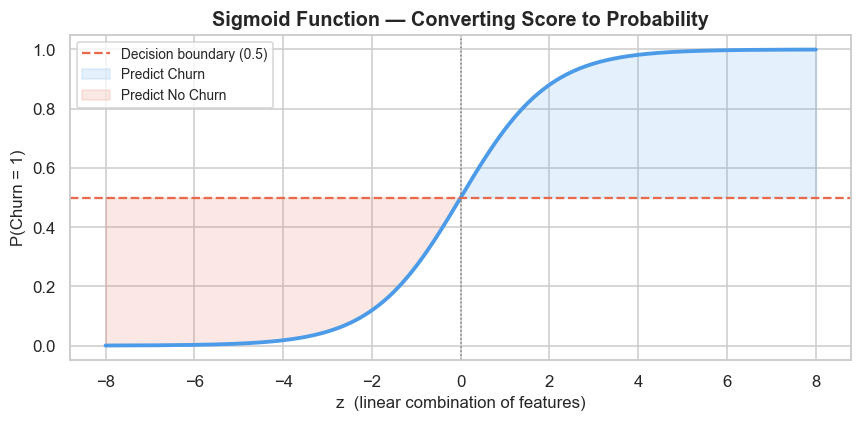

In [ ]:
#Visualise the Sigmoid Function
z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z, sigmoid, color='#4C9BE8', linewidth=2.5)
ax.axhline(0.5, color='#E8694C', linestyle='--', label='Decision boundary (0.5)')
ax.axvline(0,   color='gray',    linestyle=':', linewidth=1)
ax.fill_between(z, sigmoid, 0.5, where=(sigmoid >= 0.5), alpha=0.15, color='#4C9BE8', label='Predict Churn')
ax.fill_between(z, sigmoid, 0.5, where=(sigmoid <  0.5), alpha=0.15, color='#E8694C', label='Predict No Churn')
ax.set_xlabel('z  (linear combination of features)', fontsize=11)
ax.set_ylabel('P(Churn = 1)', fontsize=11)
ax.set_title('Sigmoid Function — Converting Score to Probability', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
#Train the Model
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)
print(" Logistic Regression model trained successfully!")
print(f"   Features used: {X_train_scaled.shape[1]}")
print(f"   Training samples: {X_train_scaled.shape[0]}")


 Logistic Regression model trained successfully!
   Features used: 8
   Training samples: 1200


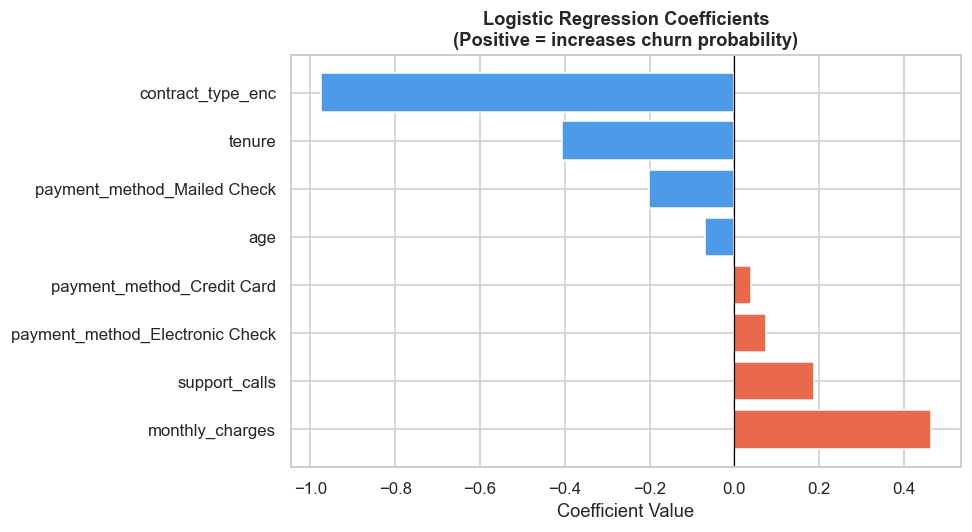


Coefficients and Odds Ratios:
                        Feature  Coefficient  Odds Ratio
                monthly_charges     0.463653    1.589872
                  support_calls     0.188534    1.207479
payment_method_Electronic Check     0.075551    1.078478
     payment_method_Credit Card     0.038816    1.039579
                            age    -0.068953    0.933370
    payment_method_Mailed Check    -0.200198    0.818569
                         tenure    -0.407441    0.665351
              contract_type_enc    -0.974764    0.377281


In [ ]:
#Feature Coefficients
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values('Coefficient', ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E8694C' if c > 0 else '#4C9BE8' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(Positive = increases churn probability)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()
print("\nCoefficients and Odds Ratios:")
print(coef_df.to_string(index=False))


---
5.Model Evaluation


In [34]:
#Predictions
y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
#Metrics
metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1-Score':  f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_prob)
}
print("MODEL EVALUATION METRICS")
for k, v in metrics.items():
    print(f"  {k:<12}: {v:.4f}")


MODEL EVALUATION METRICS
  Accuracy    : 0.5833
  Precision   : 0.3971
  Recall      : 0.5567
  F1-Score    : 0.4635
  ROC-AUC     : 0.6413


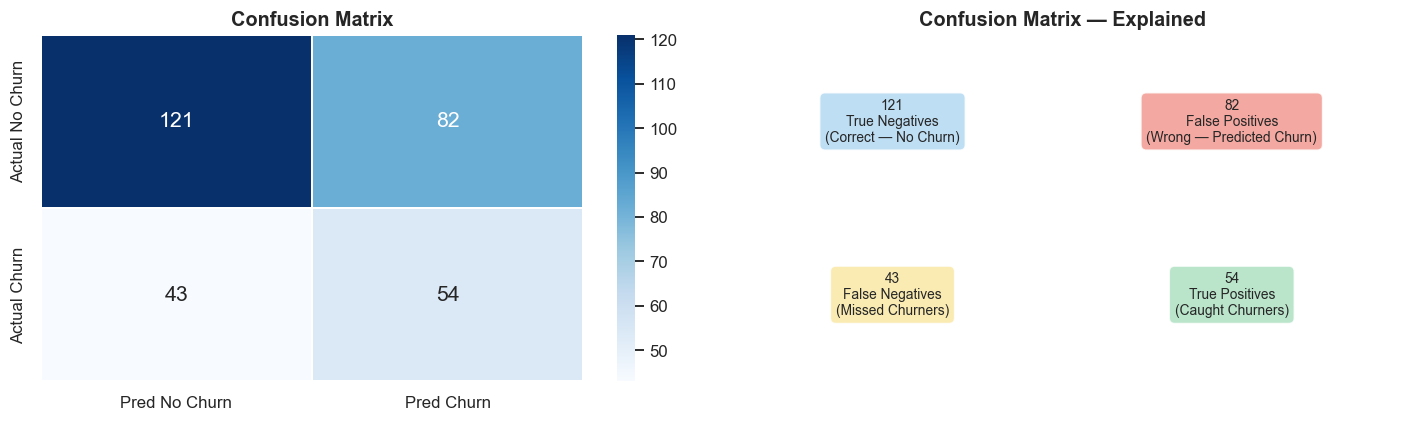


TP=54, TN=121, FP=82, FN=43
Recall (Sensitivity): 0.557  — 'Of all actual churners, we caught 55.7%'


In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred No Churn', 'Pred Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'],
            linewidths=1, linecolor='white', annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
labels_txt = [
    ['True Negatives\n(Correct — No Churn)', 'False Positives\n(Wrong — Predicted Churn)'],
    ['False Negatives\n(Missed Churners)', 'True Positives\n(Caught Churners)']
]
colors_cm = [
    ['#AED6F1', '#F1948A'],
    ['#F9E79F', '#A9DFBF']
]
for i in range(2):
    for j in range(2):
        axes[1].text(
            j + 0.5, 1.5 - i,
            f"{cm[i,j]}\n{labels_txt[i][j]}",
            ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor=colors_cm[i][j], alpha=0.8)
        )
axes[1].set_xlim(0, 2)
axes[1].set_ylim(0, 2)
axes[1].axis('off')
axes[1].set_title('Confusion Matrix — Explained', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\nTP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"Recall (Sensitivity): {tp/(tp+fn):.3f}  — 'Of all actual churners, we caught {tp/(tp+fn)*100:.1f}%'")

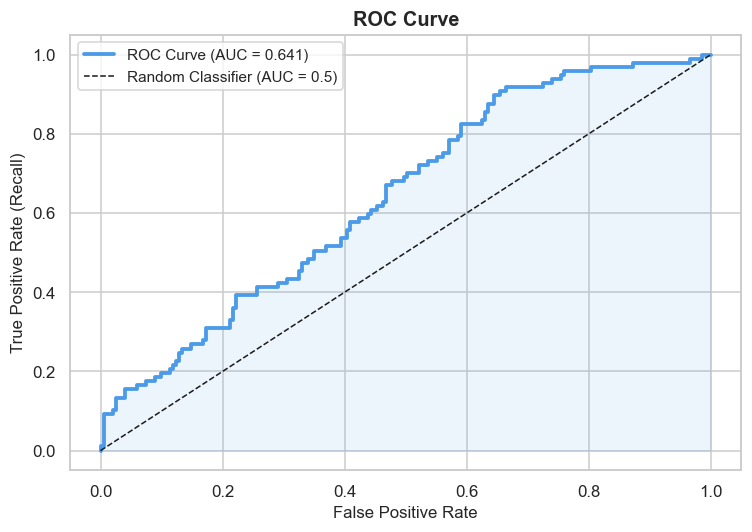


ROC-AUC = 0.6413
AUC > 0.5 means the model has discriminative power beyond random guessing.


In [ ]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#4C9BE8', linewidth=2.5, label=f'ROC Curve (AUC = {auc_score:.3f})')
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#4C9BE8')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
print(f"\nROC-AUC = {auc_score:.4f}")
print("AUC > 0.5 means the model has discriminative power beyond random guessing.")


In [ ]:
#Full Classification Report 
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.74      0.60      0.66       203
       Churn       0.40      0.56      0.46        97

    accuracy                           0.58       300
   macro avg       0.57      0.58      0.56       300
weighted avg       0.63      0.58      0.60       300



step 6:summary

. Data Creation
Created a synthetic telecom churn dataset with 1500 rows, mixed feature types, missing values, and outliers
Key Learning: Real-world datasets always contain noise → must be handled explicitly

. Exploratory Data Analysis (EDA)
Used histograms, boxplots, correlation matrix, and churn rate analysis
Found that total_charges is highly correlated with tenure × monthly_charges
Key Learning: Strong correlations indicate multicollinearity risk

. Multicollinearity Handling
Dropped total_charges
Key Learning: Highly correlated features increase variance of coefficients and reduce interpretability

. Missing Value Treatment
Used median imputation for numerical features
Used mode imputation for categorical features
Key Learning: Avoid dropping rows blindly — imputation preserves data

. Outlier Treatment
Applied IQR-based capping (Winsorization)
Key Learning: Extreme values distort model behavior; capping is better than removal

. Encoding
Used ordinal encoding for contract_type
Used one-hot encoding for payment_method
Key Learning: Encoding depends on whether the feature has an inherent order

. Feature Scaling
Applied StandardScaler to numerical features
Key Learning: Logistic Regression is sensitive to feature scale → scaling improves performance and convergence

. Class Imbalance Handling
Used class_weight='balanced' in Logistic Regression
Key Learning: Imbalanced data biases predictions → weighting helps correct it

. Sigmoid Function
Converts linear model output into probability
Then applies threshold (default = 0.5) for classification
Key Learning: Threshold can be tuned to balance precision vs recall

. Model Evaluation
Used Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix
Key Learning: Accuracy alone is misleading for imbalanced data

. Accuracy Trap
A dummy model can achieve ~75% accuracy but 0% recall
Key Learning: Always evaluate using Recall, F1, and AUC for critical problems